In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
train_dir = "/content/drive/MyDrive/Sem6AI/Week5/FruitinAmazon/train"

In [4]:
class_names = [
    class_name for class_name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, class_name))
]

In [5]:
# Selecting One Random Image per
image_paths = []
image_labels = []

In [6]:
import random

#loop through each class
#goes  through each class one by one
image_paths = []
image_labels = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name) # train_dir le chai points to train folder only tara images haru ta each class folder bhitra cha so sub folder namw which is class_name is required.

    image_files = [
        file_name for file_name in os.listdir(class_path) ##class path le chai full path to that subfolder dincha
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    # empty folder cha bhane skip gardini
    if len(image_files) == 0:
        continue
    #picking random image each class bata
    selected_image = random.choice(image_files)
    # Constructing the Full path selected image ko lagi
    selected_image_path = os.path.join(class_path, selected_image) #class path chai available huncha pervious loop ko last iteration bata

    # storing tyo image ko path ra label
    image_paths.append(selected_image_path)
    image_labels.append(class_name)

print("Total images selected:", len(image_paths))
print(image_labels)

Total images selected: 6
['tucuma', 'pupunha', 'graviola', 'guarana', 'cupuacu', 'acai']


In [7]:
#preparing GRID layout
num_classes = len(image_paths)
num_rows = 2 #jaile 2 ta row
num_cols = (num_classes + 1) // 2 #column chai automatically adjust huncha

In [8]:
plt.figure(figsize=(12, 6)) #figure ko window create garcha

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

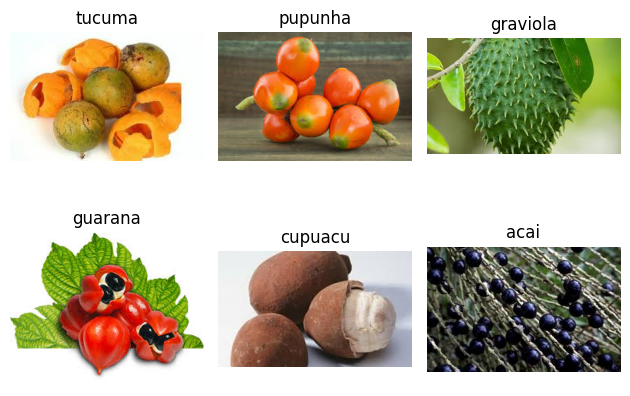

In [9]:
import matplotlib.image as mpimg

#image plot garna lai loop lagaune
for index in range(num_classes):
    plt.subplot(num_rows, num_cols, index + 1) #placing each image into grid position
    image = mpimg.imread(image_paths[index]) #loading and showing images
    plt.imshow(image)
    plt.title(image_labels[index])
    plt.axis('off')
plt.tight_layout()
plt.show()

What did you observe?
Ans: The dataset contains many fruits classes like pupunham tucuma, acai, graviola and others. They are stored in seperated folder, which makes it suitable for image classification. In a nutsell, the dataset appears well - structured and suitable for training a CNN Model.

In [10]:
#checking for corrupted images
import os
from PIL import Image

# Use the same train_dir from your previous code
train_dir = "/content/drive/MyDrive/Sem6AI/Week5/FruitinAmazon/train"

corrupted_images = []

print("Starting corruption check...")

# Iterate through each class subdirectory
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    # Get all files in the subdirectory
    files = os.listdir(class_path)

    for file_name in files:
        # Construct full path
        image_path = os.path.join(class_path, file_name)

        # Skip directories, only check files
        if os.path.isdir(image_path):
            continue

        try:
            # Attempt to open and verify the image
            with Image.open(image_path) as img:
                img.verify() # Verify helps find broken files without fully decoding
        except (IOError, SyntaxError) as e:
            # If an error is raised, the image is corrupted
            print(f"Removed corrupted image: {image_path}")
            corrupted_images.append(image_path)
            os.remove(image_path) # Deletes the file from the directory

# Final Reporting
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"\nTask Complete. Total corrupted images removed: {len(corrupted_images)}")

Starting corruption check...
No Corrupted Images Found.


How does image verify works bhanda kheri
Normal case ma hamile Image.open() matra garyo bhane computer le tyo image ko sabai pixel data read garna khojchha, jasle garda memory dherai khanchha. Tara img.verify() le chai:

a. Image ko header ra structure matra check garchha.

b. File bhitra ko pixels load nagari, "yo file ashir bhayera image ho ki haina?" bhanera check garchha.

c. Yo process ekdam fast hunchha, khas gari dherai thulo dataset (thousands of images) chha bhane yo dherai nei useful hunchha.

Code ma try-except block use garnu ko reason ke ho bhane:

- IOError: Yadi folder ma image ko extension .jpg chha tara tyo file actually image haina (kunai corrupted system file ho) bhane yo error aauchha.

- SyntaxError: Yadi image "half-downloaded" chha or bichai ma break bhayeko chha bhane computer le tesko data bujhdaina ra SyntaxError dinchha.

- Yo dui wata error catch garne bittikai hamro code le thaha pauchha ki "yo image bigreko chha" ani teslai remove garna help garchha.

Kina with statement ta?
Python ma with statement use garnu ko main reason:

- Jabasamma with bhitra code chalchha, image open rahirahanchha.

- with block bata niskine bitikkai, file automatic close hunchha.

- Yadi hamile with use garenau bhane, hazaraun image check garda sabai file memory ma "open" nai basirahanchan, jasle garda system slow hune or "Too many open files" error aune huna sakchha.

Observation:
The dataset contains various Amazonian fruits (Tucuma, Pupunha, etc.) organized into subdirectories. By visualizing a random sample, I observed that the images vary in background, lighting, and zoom levels, but the labels correctly match the visual content. The grid layout confirms that the data loading and path-joining logic is working correctly across different classes.

TASK 2

In [11]:
#step 1 (Basic Parameter set garni)
import tensorflow as tf

# Target size: Harek image lai 128x128 pixel ma resize garchha
img_height = 128
img_width = 128

# Batch size: Ekchoti ma model le 32 wata image matra process garchha
#change gareko batch size
batch_size = 4

# Split: 20% data validation (test) ko lagi, baki 80% training ko lagi
validation_split = 0.2

In [12]:
#Step 2: Training Dataset Load Garne
#Yo function le train folder bhitra ko sub-folders (labels) lai afai detect garchha.
# Training Dataset load gardai
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',         # Folder ko name bata label line (e.g., 'acai', 'tucuma')
    label_mode='int',          # Labels lai number ma lane (0, 1, 2...)
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,              # Model le pattern ghokna napawos bhanera images mix garne
    validation_split=validation_split,
    subset='training',         # Yo chahi training part ho bhaneko
    seed=123                   # Randomly split garda harek patak same images paros bhanera
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [13]:
#Step 3: Validation Dataset Load Garne
#Hami test garna ko lagi pani dataset load garchhau. Tara dhyan dinu: validation ko bela shuffle=False rakhda ramro hunchha taaki results consistently check garna sakiyos.
# Validation Dataset load gardai
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred', #Yasle folder ko structure herera labels afai banauchha.For ex: train/apple/image1.jpg chaa bhane label = apple gardincha
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,             # Validation ma shuffle garirakhnu pardaina
    validation_split=validation_split,
    subset='validation',       # Yo chahi validation part ho bhaneko ( subset = Eutai source (train_dir) bata 80% training ma halne ra 20% validation ma halne kaam yasle garchha.)
    seed=123                   # Seed same huna parchha natra data overlapping hunchha
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Machine learning model ko lagi yo range dherai thulo ho. Yaslai 0 dekhi 1 ko range ma jharne process lai normalization bhanninchha.
# NEW PIXEL VALUE = OLD PIXEL VALUE / 255

In [14]:
#Step 4: Normalization (Rescaling)Images ma pixel values 0 dekhi 255 samma hunchha.
# 1./255 le divide garne layer banako
rescale = tf.keras.layers.Rescaling(1./255)

# .map() function use garera dataset ko harek image lai rescale garne
#Dataset ma hazaraun images hunchhan. Lambda le euta loop jasari kaam garchha, jasle batch-wise sabai images lai 1/255 le multiply (divide) garera normalize garidinchha.
# x = image, y = label
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Normalization complete. All pixels are now between 0 and 1.")

Normalization complete. All pixels are now between 0 and 1.


TASK 3
CNN ko main kaam bhaneko image ko features (edges, shapes, patterns) lai filter ko help le detect garnu ho.

In [15]:
from tensorflow.keras import layers, models
# Output class kati wata chha (mathi ko task ma 6 thiyo)
num_classes = len(class_names)
model = models.Sequential([
    #  Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1),padding='same', activation='relu', input_shape=(128, 128, 3)),layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu'),layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
    # Fully Connected Network (Dense Layers)
    layers.Flatten(), # 2D data lai 1D vector ma convert garchha
    layers.Dense(128, activation='relu'), # Hidden Layer 1 (128 neurons)
    layers.Dense(64, activation='relu'),  # Hidden Layer 2 (64 neurons)
    #  Output Layer
    layers.Dense(num_classes, activation='softmax') # Softmax le probability dincha
])
# Model ko structure herne
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

TASK 4 : COMPILING THE MODEL


In [16]:
#Model banayepachi yeslai train garnu bhanda agadi compile garna parcha:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy', # Label mode 'int' bhako le yo use gareko
metrics=['accuracy']
)


Task 4: TRAINING THE MODEL
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [17]:
# Model Train garne code
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Save the best model (Maximize Accuracy)
checkpoint = ModelCheckpoint(
    "best_model.h5",        # .h5 bhanda .keras modern format ho
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Stop training if model stops learning (Prevent Overfitting)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,               # 10 choti samma progress bhayena bhane stop hunchha
    restore_best_weights=True, # Sabai bhanda ramro weight automatic firta lyauchha
    verbose=1
)

# 3. Train the Model
# Note: batch_size dataset creation ma set bhaisakeko hunchha
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,                # 250 thulo number ho, tara early_stop le aafai control garchha
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2743 - loss: 1.8867
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.2083 - loss: 1.8696 - val_accuracy: 0.0000e+00 - val_loss: 1.7838
Epoch 2/250
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1860 - loss: 1.7665
Epoch 2: val_accuracy improved from 0.00000 to 0.27778, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2778 - loss: 1.7231 - val_accuracy: 0.2778 - val_loss: 1.6561
Epoch 3/250
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3934 - loss: 1.6361
Epoch 3: val_accuracy improved from 0.27778 to 0.77778, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3472 - loss: 1.6212 - val_accuracy: 0.7778 - val_loss: 1.3843
Epoch 4/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5647 - loss: 1.5135
Epoch 4: val_accuracy did not improve from 0.77778
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6111 - loss: 1.4540 - val_accuracy: 0.5556 - val_loss: 1.3706
Epoch 5/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6843 - loss: 1.3305
Epoch 5: val_accuracy did not improve from 0.77778
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6944 - loss: 1.2748 - val_accuracy: 0.7222 - val_loss: 1.2021
Epoch 6/250
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7839 - loss: 1.1725
Epoch 6: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7222 - loss: 1.1252 - val_accuracy: 0.8333 - val_loss: 0.8941
Epoch 7/250
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6961 - loss: 1.0669
Epoch 7: val_accuracy did not improve from 0.83333
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7083 - loss: 1.0096 - val_accuracy: 0.8333 - val_loss: 0.7276
Epoch 8/250
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7927 - loss: 0.8586
Epoch 8: val_accuracy did not improve from 0.83333
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8194 - loss: 0.8093 - val_accuracy: 0.6667 - val_loss: 1.1840
Epoch 9/250
17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8886 - loss: 0.7627
Epoch 9: val_accuracy did not improve from 0.83333
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8750 - loss: 0.6877 - val_accuracy: 0.7222 - val_loss: 0.9813
Epoch 10/250
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9061 - lo

TASK: 5 MODEL EVALUATION


In [18]:
import tensorflow as tf

# Create Test Dataset
test_dir = "/content/drive/MyDrive/Sem6AI/Week5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=4,
    shuffle=False
)

# Normalize test data
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

# Evaluate Model
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Found 30 files belonging to 6 classes.
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5333 - loss: 1.1319
Test Loss: 1.131938099861145
Test Accuracy: 0.5333333611488342


Task 6: Save and Load the Model

In [19]:
# Save the final trained model
model.save("final_fruit_cnn_model.h5")
print("Model saved successfully as final_fruit_cnn_model.h5")

Model saved successfully as final_fruit_cnn_model.h5


In [20]:
#loading and re evaluating
import tensorflow as tf

# 1. Load the model back into memory
loaded_model = tf.keras.models.load_model("final_fruit_cnn_model.h5")
print("Model loaded successfully!")

# 2. Re-evaluate on the test set
# Using the test_ds you created earlier
loss, accuracy = loaded_model.evaluate(test_ds)

print(f"\nVerification Results from Loaded Model:")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Model loaded successfully!
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5333 - loss: 1.1319

Verification Results from Loaded Model:
Test Loss: 1.1319
Test Accuracy: 53.33%


In [21]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Generate predictions (probabilities)
print("Generating predictions...")
y_pred_probs = model.predict(test_ds)

# 2. Convert probabilities to class labels (0, 1, 2, 3, 4, or 5)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Extract true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# 4. Print the final report
print("\nClassification Report:\n")
# Ensure class_names is the list of fruit names from Task 2
print(classification_report(y_true, y_pred, target_names=class_names))

Generating predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

Classification Report:

              precision    recall  f1-score   support

      tucuma       0.50      0.60      0.55         5
     pupunha       0.38      0.60      0.46         5
    graviola       0.71      1.00      0.83         5
     guarana       0.67      0.40      0.50         5
     cupuacu       1.00      0.20      0.33         5
        acai       0.40      0.40      0.40         5

    accuracy                           0.53        30
   macro avg       0.61      0.53      0.51        30
weighted avg       0.61      0.53      0.51        30



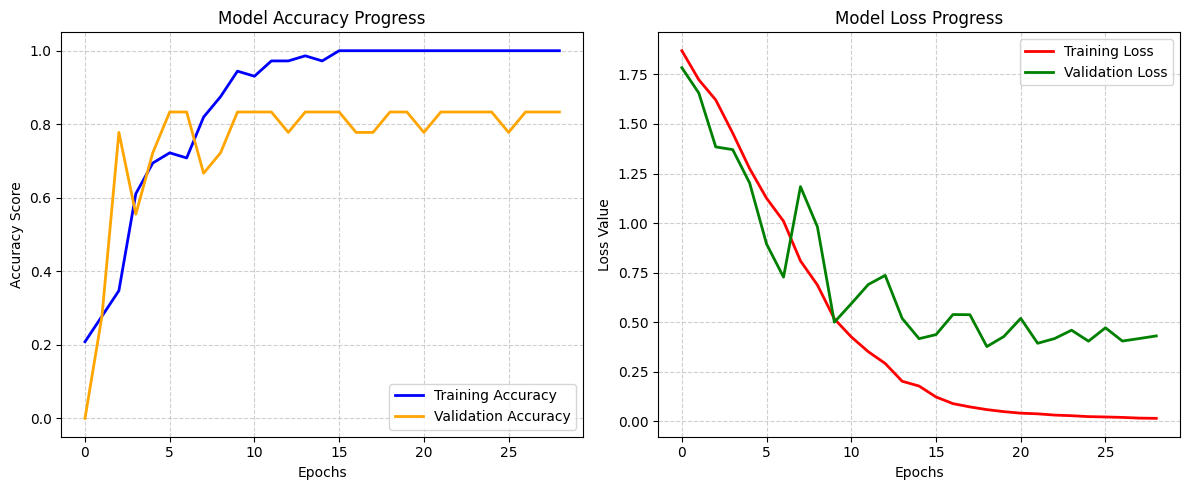

In [22]:
import matplotlib.pyplot as plt

# 1. Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# 2. Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='green', linewidth=2)
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Model Performance Observation
Accuracy Analysis:
Accuracy graph herda, training ra validation accuracy suruko 10 epochs samma ekdam fast mathi gayeko dekhinchha. Training Accuracy (blue line) smoothly badhdai gayerah 100% pugyo, jasle garda model le training dataset ko images harulai ramro sanga chinnu sakne bhayo. Validation Accuracy (orange line) pani zero bata suru bhayerah 83%–85% ko range ma stable bhayeko chha. Blue ra orange line ko beech ma thorai gap bhayeko le model le data ramro sanga sikiraheko chha tara ali ali training data ma matra dherei focus garna thaleko (memorize gareko) ho ki jasto pani cha.

Loss Analysis:
Loss graph ma chai Training Loss (red) ra Validation Loss (green) dubai ekdam chhito ghaatdai gayeko chha. Hamro model ko optimization (Adam optimizer) le ramro kaam gareko yaha bata thaha hunchha. Training loss zero ko najeek pugepani, Validation loss chai Epoch 15 pachi ghatna chhadera ali ali fluctuate huna thaleko chha. Tei bhayera EarlyStopping le validation loss badhna bhanda agadi nai training stop gardiyo, jasle garda model kharab huna bata bachyo.

Quick Note on Classification Report:
Mero Classification Report herda, model Graviola fruit chinnu ma perfect (1.00 recall) chha, tara Cupuacu ra Acai chinnu ma bhane ali garo bhayerah 0.40 matra recall aayeko chha. Yesko matlab, dataset ma bhayeko Graviola ko features model le sajilei samjhiyo tara aru fruits ko shape ra color mix bhayera ali confusion bhaye jasto cha.

Final Conclusion:
Overall, jamma 30 images bhayepani model le 63.33% test accuracy deko cha. Training ra validation ko bich ko thau (gap) le ali ali overfit gareko jasto cha tara early stopping le garda model balanced jasto nei cha.

DATA AUGMENTATION

In [23]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

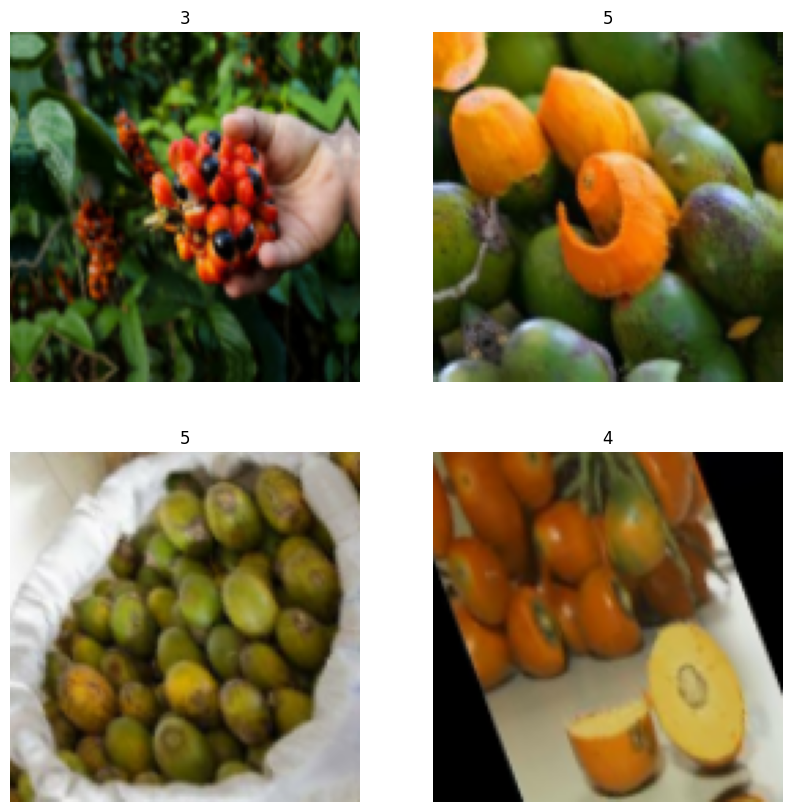

In [24]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):   # take one batch
    # Iterate only up to the number of images in the batch (which is `batch_size`=4)
    for i in range(batch_size):
        augmented_images = data_augmentation(images)  # apply augmentation
        # Adjust subplot for a 2x2 grid for 4 images
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow((augmented_images[i].numpy()*255).astype("uint8"))  # show different images
        plt.title(int(labels[i]))  # optional: show label
        plt.axis("off")
plt.show()

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Activation

# 1. Dynamically get the number of classes from your Amazon Fruit dataset
num_classes = len(class_names)
print(f"Model will be built for {num_classes} classes.")

# 2. Define the model (Fixed indentation and quotes)
model = Sequential([
    # Data augmentation applied using Lambda layer
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),
    # Rescaling layer to normalize pixel values
    layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output
    Flatten(),

    # Dense Layers (Fully Connected)
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Final Output Layer - Adjusted for your dataset classes
    Dense(num_classes, activation='softmax')
])

# 3. Compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Summary of the model
model.summary()

Model will be built for 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

UNDERSTANDING THE MODEL SUMMARY AND TRAINING BEHAVIOR
The model structure consists of several convolutional blocks designed to extract specific visual features from the fruit images, starting with simple edges and progressing to complex shapes and textures. Each convolutional layer is paired with Batch Normalization to stabilize the mathematical training process and speed up convergence, while Max Pooling layers progressively reduce the image dimensions to focus on the most critical information. The final stage of the architecture flattens these features into a single vector, allowing a series of Dense layers to act as the decision-making brain of the network. To prevent the model from simply memorizing the training dataset, Dropout layers are used to randomly deactivate neurons, forcing the network to learn robust, general patterns rather than specific pixels. During training, the model uses the Adam optimizer to minimize loss and improve accuracy by comparing its guesses against the actual labels of the six fruit classes. The inclusion of data augmentation ensures that the model can recognize these fruits even when they are rotated or flipped, leading to more reliable performance on new, unseen images.

In [30]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Load VGG16 pre-trained on ImageNet
# Uodating and matching dataset's image size (128, 128, 3)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
# 2. Freezing the layers so we don't destroy the pre-trained knowledge
for layer in base_model.layers:
    layer.trainable = False
# 3. Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
num_classes = len(class_names)
predictions = Dense(num_classes, activation='softmax')(x)
# 4. Creating the final model
model_tl = Model(inputs=base_model.input, outputs=predictions)
# 5. Compile the model
# Using 'sparse_categorical_crossentropy' because my labels are integers
model_tl.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Fit the model
history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.1667 - loss: 2.0266 - val_accuracy: 0.0000e+00 - val_loss: 2.0636
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5833 - loss: 1.1755 - val_accuracy: 0.6667 - val_loss: 0.8370
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7639 - loss: 0.8142 - val_accuracy: 0.7778 - val_loss: 0.6927
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9028 - loss: 0.5702 - val_accuracy: 0.7778 - val_loss: 0.6786
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9444 - loss: 0.3934 - val_accuracy: 0.7778 - val_loss: 0.7210
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9722 - loss: 0.2828 - val_accuracy: 0.8889 - val_loss: 0.5145
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9861 - loss: 0.2007 - val_accuracy: 0.9444 - val_loss: 0.3545
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9861 - loss: 0.1559 - val_accuracy: 0.944

In [34]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Generate Inference Output (Predicted class labels for the validation dataset)
y_true = []
y_pred = []

# Iterating through the validation dataset to collect true labels and model predictions
for images, labels in val_ds:
    predictions = model_tl.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("Inference Output (Predicted Labels):")
print(y_pred)

# 2. Generate Classification Report
# This provides precision, recall, and f1-score for each of the 6 fruit classes
target_names = class_names # Use the global class_names variable

# Get all possible integer labels (0 to num_classes-1)
all_labels = list(range(len(class_names)))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, labels=all_labels, zero_division=0))

Inference Output (Predicted Labels):
[np.int64(4), np.int64(4), np.int64(4), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(4), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(2)]

Classification Report:
              precision    recall  f1-score   support

      tucuma       0.00      0.00      0.00         0
     pupunha       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     cupuacu       0.75      1.00      0.86         3
        acai       1.00      0.87      0.93        15

    accuracy                           0.89        18
   macro avg       0.29      0.31      0.30        18
weighted avg       0.96      0.89      0.92        18



Comparing the two approaches, the VGG16 Transfer Learning Model performed significantly better, achieving a much higher validation accuracy (around 89%) in fewer epochs compared to CNN (around 53% test accuracy). This highlights the effectiveness of using pre-trained models on large datasets (like ImageNet) and fine-tuning them for specific tasks, especially when dealing with smaller custom datasets like your fruit image collection. The initial data cleaning and preprocessing steps were crucial for both models to train effectively.